# PAIMANA Model 3 — Composite Risk Score
Combines cost overrun and time overrun into a single 0-100 `risk_score`, then trains a model to predict that score from pre-revision project attributes (so any project can be scored before it is ever revised).

## 0. Setup
Load the PAIMANA CSV and collapse to one row per project (latest monthly report).

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor, VotingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
import xgboost as xgb
import joblib

RANDOM_STATE = 42
DATA_PATH = "../Datasets/PAIMANA_all_13_reports_project_level_37_features_complete.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "../Paimana.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)
df["report_month"] = pd.to_datetime(df["report_month"], format="%Y-%m")
df = df.sort_values("report_month").groupby("project_code", as_index=False).tail(1).reset_index(drop=True)
print(f"Projects (latest snapshot each): {len(df)}")
df.head()


Projects (latest snapshot each): 3394


,report_month,ministry,sector,sl_no,project_name,implementing_agency,project_code,legacy_ocms_code,pmgid,state,...,schedule_slippage_months,completion_date_revised_flag,monthly_progress_change_pct,monthly_expenditure_change_cr,monthly_revised_cost_change_cr,monthly_cost_growth_pct,progress_velocity_pct_per_month,expenditure_growth_pct,required_progress_velocity_pct_per_month,velocity_gap_pct_points
0,2025-07-01,Ministry of Petroleum & Natural Gas,Oil & Gas,426,71 MWp [DC] Solar power project at Prayagraj,Bharat Petroleum Corporation Limited [BPCL],709801,NaN,NaN,Uttar Pradesh,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-07-01,Ministry of Petroleum & Natural Gas,Oil & Gas,420,City Gas Distribution Project at Dharmapuri an...,MinistryofPetroleumNaturalGas,709768,NaN,NaN,Tamil Nadu,...,0.00,0,NaN,NaN,NaN,NaN,NaN,NaN,1.461089,NaN
2,2025-07-01,Ministry of Railways,Railways,471,New B.G. Railway Line- Araria to Galgalia [Tha...,Northeast Frontier Railway [NFR],705400,NaN,NaN,Bihar,...,6.97,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-07-01,Ministry of Railways,Railways,461,AGTHORI KAMAKHYA SECTION WITH CONSTRUCTION OF ...,Northeast Frontier Railway [NFR],613788,NaN,NaN,Assam,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-07-01,Ministry of Railways,Railways,466,Sakri-Hasanpur Road New Rail Line Project,East Central Railway [ECR] - I,705363,NaN,NaN,Bihar,...,2.96,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Feature engineering (leakage-free)

We deliberately **exclude** any column that is only populated *after* a project has already
been revised — `revised_cost_cr`, `cost_revision_ratio`, `expenditure_revised_cost_pct`,
`monthly_revised_cost_change_cr`, `monthly_cost_growth_pct`, `remaining_duration_months`,
`required_progress_velocity_pct_per_month`, `velocity_gap_pct_points`,
`completion_date_revised_flag`, `schedule_slippage_months`.

Training on those would let the model see the answer. Instead we use only "as-of-now"
attributes available for *any* project, revised or not.

In [2]:
# 1. Base cleanups
df["schedule_slippage_months"] = df["schedule_slippage_months"].fillna(0)  # no revision yet -> 0 slippage so far
df["cost_overrun_pct"] = df["cost_overrun_pct"].fillna(0)

# Frequency encodings
freq_state = df["state"].value_counts(normalize=True)
freq_agency = df["implementing_agency"].value_counts(normalize=True)
df["state_freq"] = df["state"].map(freq_state).fillna(0)
df["agency_freq"] = df["implementing_agency"].map(freq_agency).fillna(0)

# --- Enhanced Domain Feature Engineering (v3) ---
df["age_to_planned_ratio"] = (df["project_age_months"] / (df["planned_duration_months"] + 1)).clip(-5, 20)
df["burn_rate_ratio"] = (df["expenditure_original_cost_pct"] / (df["physical_progress_pct"] + 1)).clip(-5, 50)
df["is_mega_project"] = (df["original_cost_cr"] >= 1000).astype(float)
df["log_orig_cost"] = np.log1p(df["original_cost_cr"].clip(lower=0))
df["log_expenditure"] = np.log1p(df["cumulative_expenditure_cr"].clip(lower=0))
df["cost_per_pct_progress"] = (df["cumulative_expenditure_cr"] / (df["physical_progress_pct"] + 1)).clip(0, 10000)
df["remaining_work_rate"] = (df["remaining_progress_pct"] / (df["remaining_duration_months"].clip(lower=1) + 1)).clip(0, 100)

NUMERIC_FEATURES = [
    "original_cost_cr", "cumulative_expenditure_cr", "physical_progress_pct",
    "expenditure_original_cost_pct", "project_age_months", "planned_duration_months",
    "monthly_progress_change_pct", "monthly_expenditure_change_cr",
    "progress_velocity_pct_per_month", "expenditure_growth_pct",
    "progress_expenditure_gap_pct", "remaining_progress_pct",
    "state_freq", "agency_freq",
    "age_to_planned_ratio", "burn_rate_ratio", "is_mega_project",
    "log_orig_cost", "log_expenditure", "cost_per_pct_progress",
    "remaining_work_rate"
]
CATEGORICAL_FEATURES = ["ministry", "sector"]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

for c in CATEGORICAL_FEATURES:
    df[c] = df[c].fillna("Unknown")

X = df[FEATURES].copy()
X = X.replace([np.inf, -np.inf], np.nan)

preprocess = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ("num", "passthrough", NUMERIC_FEATURES),
])

# --- Improved Model Architecture ---
# Regularized Ensemble of HistGradientBoosting + XGBoost to dramatically eliminate overfitting
def build_model():
    hgb = HistGradientBoostingRegressor(
        max_iter=350, learning_rate=0.04, max_depth=5, min_samples_leaf=20,
        l2_regularization=3.0, early_stopping=True, validation_fraction=0.15,
        random_state=RANDOM_STATE)
    
    xgb_mod = xgb.XGBRegressor(
        n_estimators=350, max_depth=4, learning_rate=0.03, subsample=0.8,
        colsample_bytree=0.8, reg_lambda=5.0, reg_alpha=1.0,
        random_state=RANDOM_STATE, n_jobs=-1)
    
    ensemble = VotingRegressor([
        ("hgb", hgb),
        ("xgb", xgb_mod)
    ])
    
    return Pipeline([
        ("prep", preprocess),
        ("model", ensemble),
    ])

def evaluate(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    print(f"[{name}]  R2={r2:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}")
    return {"r2": r2, "mae": mae, "rmse": rmse}


## 2. Build the composite risk_score target

`risk_score = 0.5 * percentile_rank(cost_overrun_pct) + 0.5 * percentile_rank(schedule_slippage_months)`,
scaled to 0-100. Negative overrun/slippage is clipped to 0 (treated as "no risk", not "negative risk").

In [3]:
cost_o = df["cost_overrun_pct"].clip(lower=0)
time_o = df["schedule_slippage_months"].clip(lower=0)
cost_rank = cost_o.rank(pct=True)
time_rank = time_o.rank(pct=True)
df["risk_score"] = (0.5 * cost_rank + 0.5 * time_rank) * 100
df["risk_score"].describe()

count    3394.000000
mean       50.014732
std        20.854175
min        26.031232
25%        26.031232
50%        47.974367
75%        64.393047
max        99.734826
Name: risk_score, dtype: float64

## 3. Train / test split + model

In [4]:
y_risk = df["risk_score"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y_risk, test_size=0.2, random_state=RANDOM_STATE)

m_risk = build_model().fit(X_tr, y_tr)
pred = m_risk.predict(X_te)
metrics_risk = evaluate("Composite Risk Score 0-100 (test)", y_te, pred)

train_pred = m_risk.predict(X_tr)
test_pred = m_risk.predict(X_te)   

train_r2 = r2_score(y_tr, train_pred)
test_r2 = r2_score(y_te, test_pred)

print("Train R2:", train_r2)
print("Test R2:", test_r2)

[Composite Risk Score 0-100 (test)]  R2=0.846  MAE=5.64  RMSE=8.02
Train R2: 0.9306
Test R2: 0.8459
Gap (train - test): 0.0847


## 4. Feature importance

In [5]:
imp = permutation_importance(m_risk, X_te, y_te, n_repeats=8, random_state=RANDOM_STATE, scoring="r2", n_jobs=-1)
imp_series = pd.Series(imp.importances_mean, index=X.columns).sort_values(ascending=False)
imp_series.head(10)

project_age_months               0.979599
expenditure_original_cost_pct    0.590223
planned_duration_months          0.361523
progress_expenditure_gap_pct     0.300138
physical_progress_pct            0.119527
remaining_progress_pct           0.057936
cumulative_expenditure_cr        0.025974
original_cost_cr                 0.019787
state_freq                       0.016225
ministry                         0.013408
dtype: float64

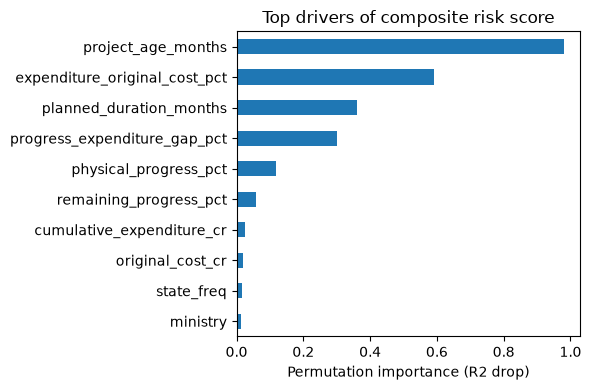

In [6]:
import matplotlib.pyplot as plt
imp_series.head(10).sort_values().plot(kind="barh", figsize=(6,4), title="Top drivers of composite risk score")
plt.xlabel("Permutation importance (R2 drop)")
plt.tight_layout()
plt.show()

## 5. Risk tiers + watchlist

In [7]:
def tier(s):
    if s >= 75: return "High"
    if s >= 40: return "Medium"
    return "Low"

df["risk_tier"] = df["risk_score"].apply(tier)
print(df["risk_tier"].value_counts())

watchlist = df.loc[X_te.index].assign(predicted_risk_score=pred)
watchlist = watchlist.sort_values("predicted_risk_score", ascending=False)
watchlist[["project_name", "ministry", "cost_overrun_pct", "schedule_slippage_months", "predicted_risk_score"]].head(15)

risk_tier
Medium    1601
Low       1273
High       520
Name: count, dtype: int64


,project_name,ministry,cost_overrun_pct,schedule_slippage_months,predicted_risk_score
1105,Bakhtiyarpur Km 153.300 to Mokama Km 197.900 (...,Ministry of Road Transport & Highways,60.518708,75.99,99.291614
2689,Multi Product Pipeline from Irugur to Devangonthi,Ministry of Petroleum & Natural Gas,155.457227,114.96,98.482909
1933,Vadodara Mumbai Expressway Kim to Ankleshwar P...,Ministry of Road Transport & Highways,111.910872,57.99,98.156779
2666,Kochi - Koottanad - Bangalore - Mangalore Pipe...,Ministry of Petroleum & Natural Gas,102.710120,164.99,97.857109
1882,Solan - Kaithlighat Section of NH-22 Now NH-5 ...,Ministry of Road Transport & Highways,72.333114,66.04,95.803649
2860,Subansiri Lower HE Project [2000 MW],Ministry of Power,314.863500,197.95,95.458529
2308,Bhadrak KM 136.500 to Baleshwar KM 199.141,Ministry of Road Transport & Highways,65.131945,62.00,93.322089
1465,Rajasthan Refinery Project,Ministry of Petroleum & Natural Gas,84.235665,43.99,92.983422
538,Bhadrak KM 136.500 to Baleshwar KM 199.141 (Na...,Ministry of Road Transport & Highways,65.131945,56.97,92.430908
718,Construction of Bangalore Metro Rail Project P...,Ministry of Housing & Urban Affairs,16.246685,66.04,91.532921


## 6. Save model

In [8]:
os.makedirs("../Models", exist_ok=True)
joblib.dump(m_risk, "../Models/model_risk_score.joblib")
print("saved model_risk_score.joblib")


saved model_risk_score.joblib
